# Waterstanden in Provincie Zuid-Holland

## 1. Inleiding

Waterstanden zijn belangrijk voor regionaal waterbeheer en waterveiligheid. In Zuid-Holland spelen verschillende invloeden tegelijk een rol, zoals getij, wind, neerslag, rivierafvoer en de ligging van een meetstation.

Dit notebook is een verkennend data-engineeringproject. Het doel is om openbare RWS-data op te halen, op te schonen en om te zetten naar analyseklare datasets. Daarna worden enkele eenvoudige visualisaties gemaakt om patronen in de waterstanden beter te begrijpen.

In dit notebook wordt verkend:

- hoe gemeten waterstanden zich ontwikkelen in de periode 2022-2025;
- welke verschillen zichtbaar zijn tussen meetstations aan de kust en meer landinwaarts;
- hoe gemeten waterstanden verschillen van astronomische waterhoogte als getijreferentie;
- in welke maanden relatief hoge waterstanden vaker voorkomen.


## 2. Data

In deze analyse is gebruikgemaakt van openbare data van Rijkswaterstaat via de DDL API (https://github.com/Deltares/ddlpy). De belangrijkste dataset bestaat uit 10-minutenmetingen van waterhoogte (`WATHTE`) in oppervlaktewater (`OW`).

De analyse richt zich op acht meetstations in en rond Zuid-Holland:

- Hoek van Holland
- Scheveningen
- Vlaardingen
- Rotterdam
- Spijkenisse
- Dordrecht
- Krimpen aan den IJssel
- Gouda

Deze selectie geeft een eenvoudige route van kust naar binnenland. Daardoor is het mogelijk om meetstations met een sterkere kust- of getij-invloed te vergelijken met meetstations die meer landinwaarts liggen.

Naast gemeten waterstanden wordt ook astronomische waterhoogte opgehaald. Dit is een berekende waterstand op basis van het getij. Wind, storm, neerslag en rivierafvoer zitten daar niet direct in. De astronomische reeks wordt daarom gebruikt als eenvoudige vergelijking met de gemeten waterstanden.


## 3. Werkwijze en datapipeline

De data is verwerkt via een bronze -> silver -> gold-structuur:

- Bronze: ruwe DDL-data ophalen en opslaan als Parquet, zodat de API niet bij elke run opnieuw bevraagd hoeft te worden.
- Silver: data opschonen, kwaliteitscodes filteren, tijdvelden standaardiseren en handige tijdskenmerken toevoegen.
- Gold: daggemiddelden, maandgemiddelden en seizoensstatistieken maken voor analyse en visualisatie.

Deze structuur maakt het project beter reproduceerbaar: ruwe data, opgeschoonde data en analyseklare data blijven van elkaar gescheiden. Daarna worden de resultaten onderzocht met een aantal verkennende grafieken en een kaart.


[## 4. Installatie & imports]: #

De benodigde Python-packages worden geladen en de mappen voor Bronze, Silver, Gold en plots worden aangemaakt. 


In [1]:
# relevante packages importeren
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import ddlpy
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd


# mappen aanmaken
base_path = Path('.')
bronze_path = base_path / 'data' / 'bronze'
silver_path = base_path / 'data' / 'silver'
gold_path = base_path / 'data' / 'gold'
plots_path = base_path / 'plots'
for map_pad in [bronze_path, silver_path, gold_path, plots_path]:
    map_pad.mkdir(parents=True, exist_ok=True)

# plotstijl
achtergrond_kleur = '#F7F6F2'
grafiek_kleuren = ['#20808D', '#A84B2F', '#1B474D', '#944454', '#FFC553', '#848456', '#5B8DB8', '#7B5EA7']
plt.rcParams.update({
    'figure.facecolor': achtergrond_kleur,
    'axes.facecolor': achtergrond_kleur,
    'font.family': 'DejaVu Sans',
    'figure.dpi': 150,
})

start_datum = '2022-01-01'
eind_datum = '2025-12-31'
jaartallen = [2022, 2023, 2024, 2025]

# print('Imports en instellingen geladen')
# print(f'Periode: {start_datum} t/m {eind_datum}')

## 4. Bronze - ruwe data ophalen

In de Bronze-laag wordt de RWS DDL-catalogus opgehaald en gefilterd op waterhoogte (`WATHTE`), oppervlaktewater (`OW`) en een Zuid-Hollandse bounding box.


### 4.1 RWS DD api - datacatalogus filteren

Deze stap laat zien welke DDL-locaties voldoen aan de basiscriteria voor waterstandsmetingen in Zuid-Holland.


In [2]:
# print('DDL-datacatalogus ophalen...')
locaties = ddlpy.locations()

# Basisfilter: waterhoogte in oppervlaktewater binnen Zuid-Hollandse bounding box
zh_locs = locaties[
    (locaties['Grootheid.Code'] == 'WATHTE') & # waterhoogte
    (locaties['Compartiment.Code'] == 'OW') & # oppervlakte water
    (locaties['Lat'].between(51.64, 52.34)) & # lengte- en breedtegraden voor meetstations in Zuid-Holland
    (locaties['Lon'].between(3.84, 5.04)) &   
    (locaties['Parameter_Wat_Omschrijving'].str.contains('Normaal Amsterdams Peil', na=False)) &
    (~locaties['Parameter_Wat_Omschrijving'].str.contains('astronomisch|verwachting', case=False, na=False))
].copy()

zh_locs = zh_locs[~zh_locs.index.duplicated(keep='first')]
print(f'Kandidaat-meetstations in Zuid-Holland: {zh_locs.index.nunique()}')


Kandidaat-meetstations in Zuid-Holland: 128


### 4.2 Selectie van meetstations

De uiteindelijke selectie bestaat uit acht meetstations: Hoek van Holland, Scheveningen, Vlaardingen, Rotterdam, Spijkenisse, Dordrecht, Krimpen aan den IJssel en Gouda. Samen geven deze meetstations een beeld van de kust, Nieuwe Waterweg/Nieuwe Maas, Oude Maas en Hollandsche IJssel.


In [3]:
meetstations_selectie = {
    'hoekvanholland': 'Hoek van Holland',
    'scheveningen': 'Scheveningen',
    'vlaardingen': 'Vlaardingen',
    'rotterdam.nieuwemaas.boerengat': 'Rotterdam',
    'spijkenisse.oudemaas': 'Spijkenisse',
    'dordrecht.oudemaas.benedenmerwede': 'Dordrecht',
    'krimpenaandeijssel.hollandscheijssel': 'Krimpen a/d IJssel',
    'gouda.hollandscheijssel': 'Gouda',
}

meetstations = zh_locs.loc[list(meetstations_selectie.keys())].copy()
meetstations['portfolio_naam'] = meetstations.index.map(meetstations_selectie)
meetstations[['Naam', 'portfolio_naam', 'Lat', 'Lon', 'Parameter_Wat_Omschrijving']].to_parquet(bronze_path / 'meetstations.parquet')

print(f'{len(meetstations)} meetstations geselecteerd:')
meetstations[['portfolio_naam', 'Naam', 'Lat', 'Lon']]


8 meetstations geselecteerd:


,portfolio_naam,Naam,Lat,Lon
Code,,,,
hoekvanholland,Hoek van Holland,Hoek van Holland,51.976899,4.119827
scheveningen,Scheveningen,Scheveningen,52.099035,4.263563
vlaardingen,Vlaardingen,Vlaardingen,51.899639,4.349048
rotterdam.nieuwemaas.boerengat,Rotterdam,"Rotterdam, Nieuwe Maas, Boerengat",51.918400,4.500300
spijkenisse.oudemaas,Spijkenisse,"Spijkenisse, Oude Maas",51.861661,4.333954
dordrecht.oudemaas.benedenmerwede,Dordrecht,"Dordrecht Oude Maas, Beneden Merwede",51.820000,4.671000
krimpenaandeijssel.hollandscheijssel,Krimpen a/d IJssel,"Krimpen aan de IJssel, Hollandsche IJssel",51.916500,4.579000
gouda.hollandscheijssel,Gouda,Gouda Hollandsche IJssel,52.006580,4.719720


### 4.3 Waterstandsmetingen ophalen

De 10-minutenmetingen worden per meetstation en per jaar opgehaald. De resultaten worden als Parquet opgeslagen, zodat de API niet bij elke notebook-run opnieuw hoeft te worden aangevraagd.


In [4]:
bronze_parquet_path = bronze_path / ('rws_waterstand_zh' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet')

if bronze_parquet_path.exists():
    print('Parquetbestand gevonden: data inladen')
    bronze_data = pd.read_parquet(bronze_parquet_path)
else:
    print('Geen parquetbestand gevonden: data ophalen via DDL API')
    delen = []

    for code, naam in meetstations_selectie.items():
        locatie = meetstations.loc[code]
        for jaar in jaartallen:
            print(f'Ophalen: {naam} {jaar}')
            deel = ddlpy.measurements(
                locatie,
                start_date=f'{jaar}-01-01',
                end_date=f'{jaar}-12-31',
            )
            deel['meetstation_code'] = code
            deel['meetstation_naam'] = naam
            deel['lat'] = locatie['Lat']
            deel['lon'] = locatie['Lon']
            delen.append(deel)

    bronze_data = pd.concat(delen).reset_index(names='tijdstip')
    bronze_data.to_parquet(bronze_parquet_path, index=False)

bronze_data['tijdstip'] = pd.to_datetime(bronze_data['tijdstip'])
print(f'Bronze-data, aantal records: {len(bronze_data):,}')
print(f'Meetstations: {bronze_data["meetstation_naam"].nunique()}')
bronze_data.head(6)


Parquetbestand gevonden: data inladen
Bronze-data, aantal records: 1,712,599
Meetstations: 8


,tijdstip,WaarnemingMetadata.Statuswaarde,WaarnemingMetadata.Bemonsteringshoogte,WaarnemingMetadata.Referentievlak,WaarnemingMetadata.OpdrachtgevendeInstantie,WaarnemingMetadata.Kwaliteitswaardecode,Compartiment.Code,Compartiment.Omschrijving,Grootheid.Code,Grootheid.Omschrijving,...,Meetwaarde.Waarde_Numeriek,Code,Coordinatenstelsel,Naam,Lon,Lat,meetstation_code,meetstation_naam,lat,lon
0,2022-01-01 01:00:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,136.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827
1,2022-01-01 01:10:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,131.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827
2,2022-01-01 01:20:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,128.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827
3,2022-01-01 01:30:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,124.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827
4,2022-01-01 01:40:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,121.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827
5,2022-01-01 01:50:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,...,119.0,hoekvanholland,ETRS89,Hoek van Holland,4.119827,51.976899,hoekvanholland,Hoek van Holland,51.976899,4.119827


## 5. Silver - data cleaning

In de Silver-laag worden de ruwe metingen opgeschoond. Tijdstippen worden gestandaardiseerd, waterstanden worden als centimeters t.o.v. NAP vastgelegd en er worden tijdskenmerken toegevoegd zoals jaar, maand, dag, uur en seizoen.


In [5]:
silver_data = bronze_data.copy()

# Waterstand staat in de DDL-data al in centimeters t.o.v. NAP.
silver_data['waterstand_cm'] = pd.to_numeric(silver_data['Meetwaarde.Waarde_Numeriek'], errors='coerce')
silver_data['tijdstip'] = pd.to_datetime(silver_data['tijdstip'])

# Alleen bruikbare metingen bewaren.
kwaliteit_kolom = 'WaarnemingMetadata.Kwaliteitswaardecode'
n_voor = len(silver_data)
silver_data = silver_data[silver_data['waterstand_cm'].notna()]
silver_data = silver_data[silver_data['waterstand_cm'] > -9999] 
silver_data = silver_data[silver_data[kwaliteit_kolom].isin(['00', '10', '20', '25'])]

# Tijdkenmerken toevoegen.
silver_data['datum'] = silver_data['tijdstip'].dt.date
silver_data['jaar'] = silver_data['tijdstip'].dt.year
silver_data['maand'] = silver_data['tijdstip'].dt.month
silver_data['dag'] = silver_data['tijdstip'].dt.day
silver_data['uur'] = silver_data['tijdstip'].dt.hour
silver_data['seizoen'] = silver_data['maand'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Lente', 4: 'Lente', 5: 'Lente',
    6: 'Zomer', 7: 'Zomer', 8: 'Zomer',
    9: 'Herfst', 10: 'Herfst', 11: 'Herfst',
})

silver_data = silver_data[[
    'tijdstip', 'datum', 'meetstation_code', 'meetstation_naam', 'lat', 'lon',
    'waterstand_cm', 'jaar', 'maand', 'dag', 'uur', 'seizoen'
]].reset_index(drop=True)

silver_data.to_parquet(silver_path / ('waterstand_silver' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet'), index=False)

print(f'Silver_data, aantal records: {len(silver_data):,} ({n_voor - len(silver_data):,} verwijderd)')
print(f'Waterstand: {silver_data["waterstand_cm"].min():.0f} t/m {silver_data["waterstand_cm"].max():.0f} cm t.o.v. NAP')
silver_data.head(6)


Silver_data, aantal records: 1,712,101 (498 verwijderd)
Waterstand: -147 t/m 313 cm t.o.v. NAP


,tijdstip,datum,meetstation_code,meetstation_naam,lat,lon,waterstand_cm,jaar,maand,dag,uur,seizoen
0,2022-01-01 01:00:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,136.0,2022,1,1,1,Winter
1,2022-01-01 01:10:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,131.0,2022,1,1,1,Winter
2,2022-01-01 01:20:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,128.0,2022,1,1,1,Winter
3,2022-01-01 01:30:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,124.0,2022,1,1,1,Winter
4,2022-01-01 01:40:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,121.0,2022,1,1,1,Winter
5,2022-01-01 01:50:00+01:00,2022-01-01,hoekvanholland,Hoek van Holland,51.976899,4.119827,119.0,2022,1,1,1,Winter


## 6. Gold - analyseklare datasets

In de Gold-laag worden daggemiddelden, maandgemiddelden en seizoensstatistieken gemaakt. De tabellen worden hiermee geschikt gemaakt voor visualisaties, dashboards of verdere analyse.


In [6]:
# daggemiddelden per meetstation
gold_dag = (
    silver_data
    .groupby(['meetstation_code', 'meetstation_naam', 'lat', 'lon', 'datum'])['waterstand_cm']
    .agg(gemiddelde='mean', minimum='min', maximum='max', n_metingen='count')
    .reset_index()
)
gold_dag['datum'] = pd.to_datetime(gold_dag['datum'])
gold_dag['maand'] = gold_dag['datum'].dt.month

# maandgemiddelden per meetstation
gold_maand = (
    silver_data
    .groupby(['meetstation_code', 'meetstation_naam', 'jaar', 'maand'])['waterstand_cm']
    .agg(gemiddelde='mean', minimum='min', maximum='max')
    .reset_index()
)

# seizoensstatistieken per meetstation
gold_seizoen = (
    silver_data
    .groupby(['meetstation_code', 'meetstation_naam', 'seizoen'])['waterstand_cm']
    .agg(gemiddelde='mean', minimum='min', maximum='max')
    .reset_index()
)

gold_dag.to_parquet(gold_path / ('waterstand_daggemiddeld' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet'), index=False)
gold_maand.to_parquet(gold_path / ('waterstand_maandgemiddeld' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet'), index=False)
gold_seizoen.to_parquet(gold_path / ('waterstand_seizoen' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet'), index=False)

print(f'Daggemiddelden: {len(gold_dag):,} records')
print(f'Maandgemiddelden: {len(gold_maand):,} records')
print(f'Seizoenen: {len(gold_seizoen):,} records')
print('\nGemiddelde waterstand per meetstation (cm t.o.v. NAP):')
print(silver_data.groupby('meetstation_naam')['waterstand_cm'].mean().round(1).sort_values().to_string())


Daggemiddelden: 11,688 records
Maandgemiddelden: 384 records
Seizoenen: 32 records

Gemiddelde waterstand per meetstation (cm t.o.v. NAP):
meetstation_naam
Scheveningen          11.0
Hoek van Holland      17.5
Vlaardingen           28.6
Spijkenisse           29.9
Rotterdam             31.2
Gouda                 35.6
Krimpen a/d IJssel    36.4
Dordrecht             50.3


## 7. Visualisaties

De visualisaties richten zich op het beantwoorden van praktische vragen, zoals: hoe ontwikkelen gemeten waterstanden zich door de tijd, hoe ziet de astronomische waterstand eruit, is er een seizoenspatroon, wanneer komen hoge waterstanden voor, hoe ziet het uurprofiel eruit en waar liggen de meetstations?


In [7]:
meetstations_volgorde = [
    'Scheveningen', 'Hoek van Holland', 'Vlaardingen', 'Rotterdam',
    'Spijkenisse', 'Dordrecht', 'Krimpen a/d IJssel', 'Gouda'
]

meetstations_kleuren = dict(zip(meetstations_volgorde, grafiek_kleuren))
maanden_list = ['Jan','Feb','Mrt','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']


## Visualisatie 1a - gemeten daggemiddelde waterstand per meetstation

Onderstaande grafiek toont de gemeten daggemiddelde waterstand per meetstation. In deze metingen zitten meerdere invloeden tegelijk, zoals getij, wind, rivierafvoer en lokale omstandigheden.


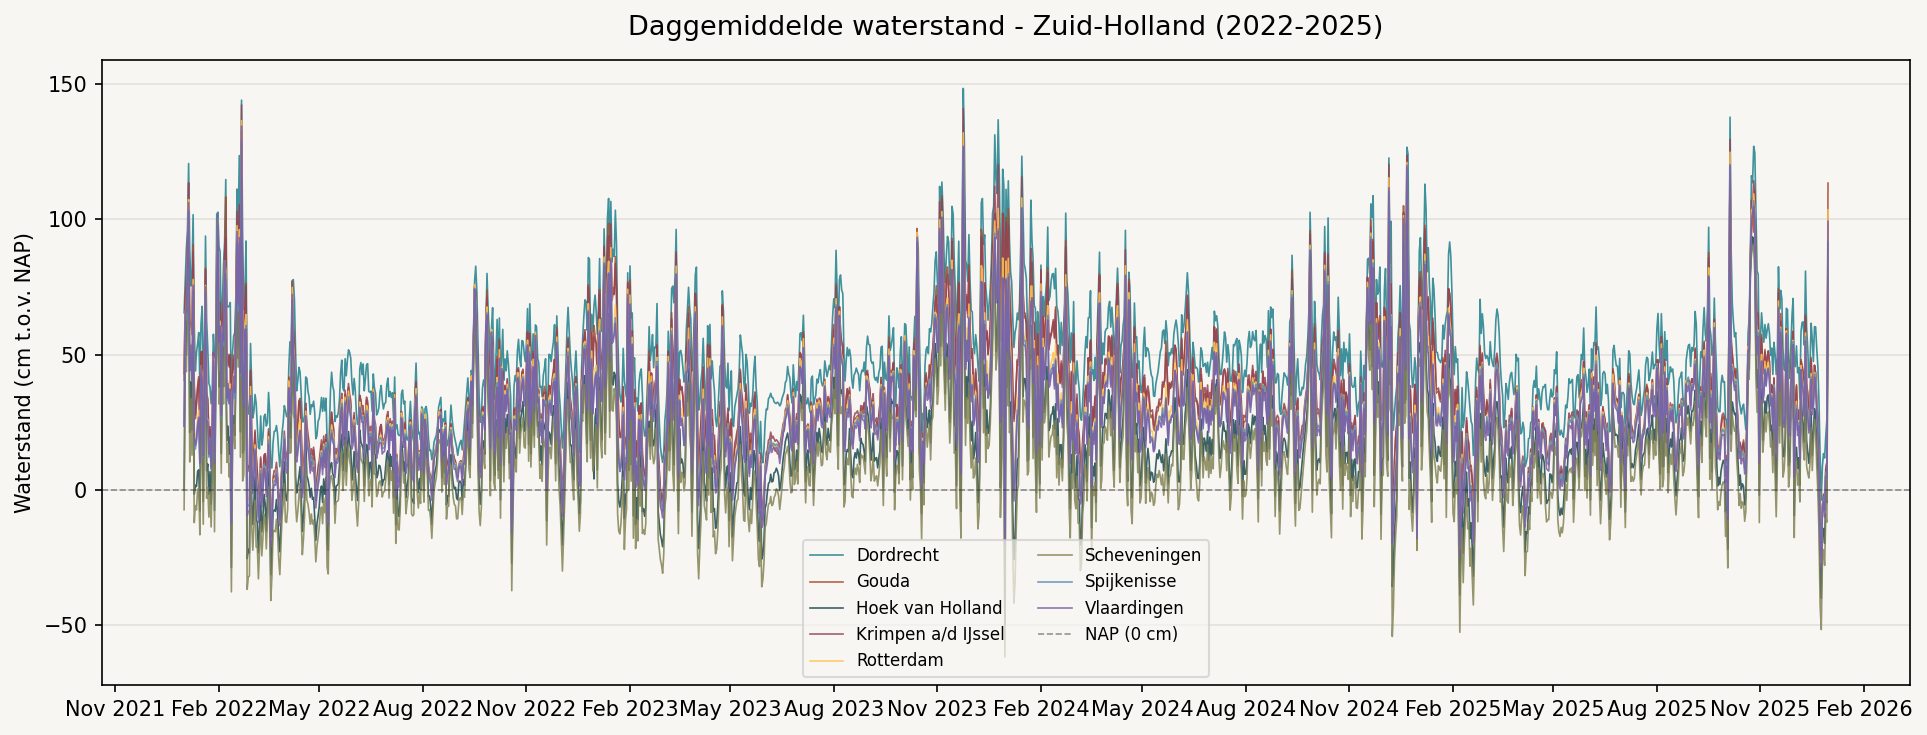

In [8]:
fig, ax = plt.subplots(figsize=(13, 5), facecolor=achtergrond_kleur)
ax.set_facecolor(achtergrond_kleur)

for i, (code, groep) in enumerate(gold_dag.sort_values('datum').groupby('meetstation_code')):
    naam = groep['meetstation_naam'].iloc[0]
    ax.plot(
        groep['datum'], groep['gemiddelde'],
        color=grafiek_kleuren[i % len(grafiek_kleuren)], linewidth=0.8,
        label=naam, alpha=0.85
    )

ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5, label='NAP (0 cm)')
ax.set_title('Daggemiddelde waterstand - Zuid-Holland (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=13, pad=12)
ax.set_ylabel('Waterstand (cm t.o.v. NAP)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(fontsize=8, ncol=2, framealpha=0.7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plots_path / ('vis1a_daggemiddelden' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- De lijnen zijn grilliger dan de astronomische waterhoogte in Visualisatie 1b. Dat is logisch, omdat gemeten waterstanden meer bevatten dan alleen getij.
- In sommige perioden lijken meerdere meetstations tegelijk hogere waarden te hebben. Dat kan komen door bredere omstandigheden, zoals wind, storm of hogere rivierafvoer.
- Met alleen waterstandsdata kan ik de oorzaak nog niet zeker bepalen. Daarvoor zou ik de data kunnen koppelen aan wind-, neerslag- of rivierafvoerdata.
- Voor waterbeheer kan zo'n vergelijking nuttig zijn, omdat tegelijk stijgende meetstations kunnen wijzen op een situatie die extra aandacht vraagt.


## Visualisatie 1b - astronomische waterstand per meetstation

Onderstaande grafiek toont de astronomische waterstand. Dit is de berekende waterhoogte door het getij. De grafiek is bedoeld als vergelijking met de gemeten waterstanden in Visualisatie 1a.


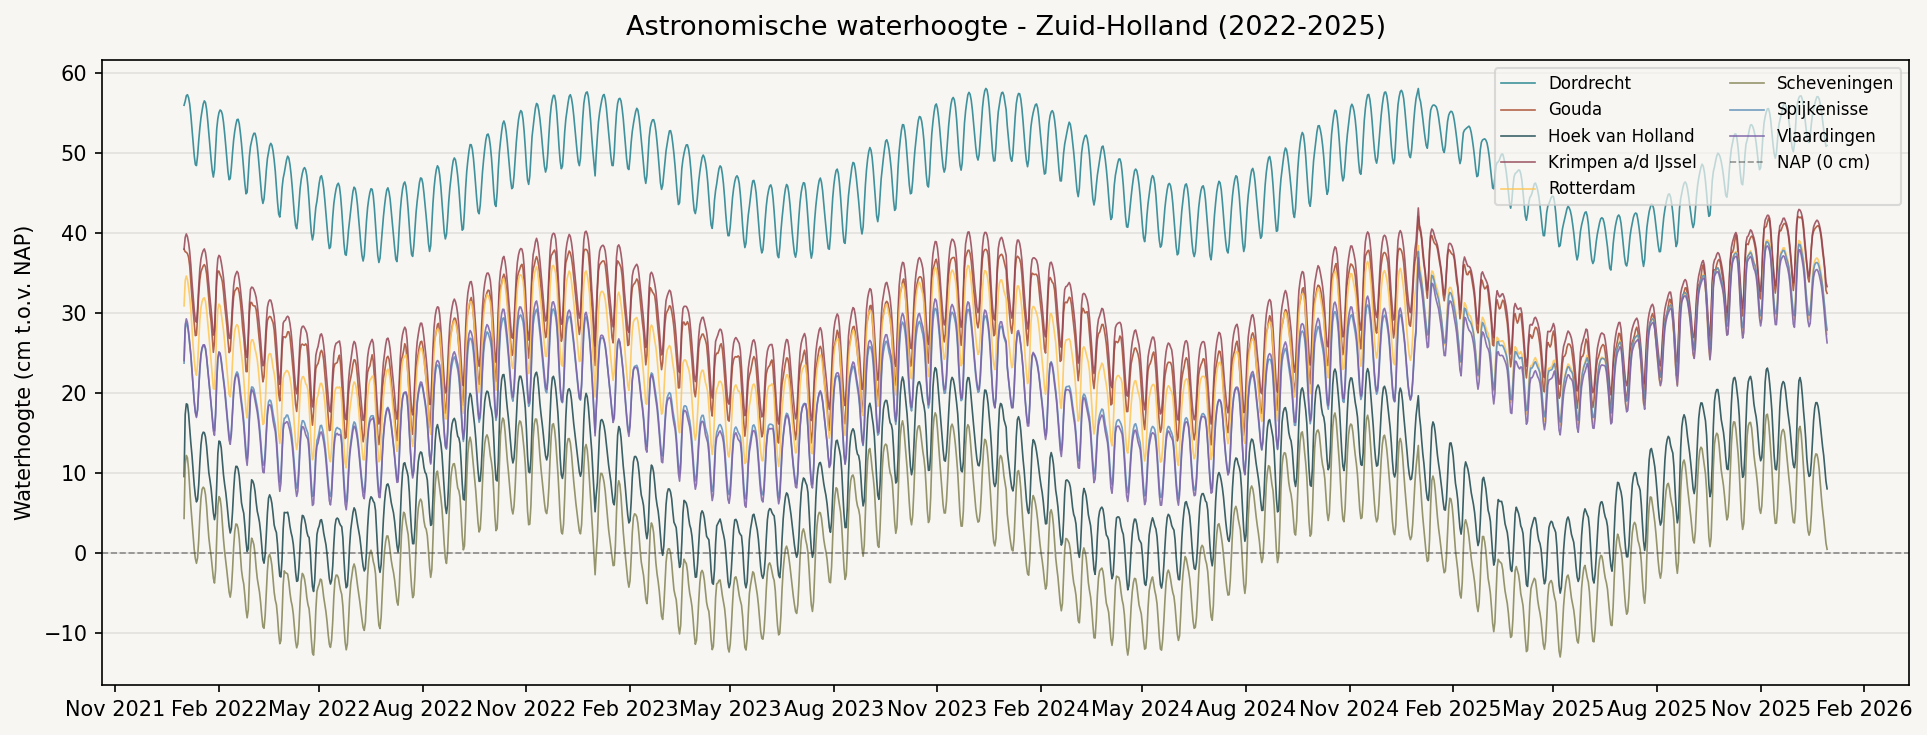

In [9]:
astro_path = bronze_path / ('astronomische_waterhoogte_zh' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.parquet')

if astro_path.exists():
    astro_raw = pd.read_parquet(astro_path)
else:
    locaties = ddlpy.locations()
    delen = []

    for code, naam in meetstations_selectie.items():
        kandidaten = locaties[
            (locaties.index == code) &
            (locaties['Grootheid.Code'] == 'WATHTE') &
            (locaties['Parameter_Wat_Omschrijving'].str.contains('astronomisch', case=False, na=False))
        ]

        if kandidaten.empty:
            print(f'Geen astronomische waterhoogte gevonden voor {naam}')
            continue

        locatie = kandidaten.iloc[0]
        for jaar in jaartallen:
            print(f'Astronomische waterhoogte ophalen: {naam} {jaar}')
            deel = ddlpy.measurements(locatie, start_date=f'{jaar}-01-01', end_date=f'{jaar}-12-31')
            deel['meetstation_code'] = code
            deel['meetstation_naam'] = naam
            delen.append(deel)

    astro_raw = pd.concat(delen).reset_index(names='tijdstip')
    astro_raw.to_parquet(astro_path, index=False)

astro = astro_raw.copy()
astro['tijdstip'] = pd.to_datetime(astro['tijdstip'])
astro['datum'] = astro['tijdstip'].dt.date
astro['waterhoogte_cm'] = pd.to_numeric(astro['Meetwaarde.Waarde_Numeriek'], errors='coerce')

astro_dag = (
    astro.dropna(subset=['waterhoogte_cm'])
    .groupby(['meetstation_code', 'meetstation_naam', 'datum'])['waterhoogte_cm']
    .agg(gemiddelde='mean', n_metingen='count')
    .reset_index()
)
astro_dag = astro_dag[astro_dag['n_metingen'] >= 100].copy()
astro_dag['datum'] = pd.to_datetime(astro_dag['datum'])

fig, ax = plt.subplots(figsize=(13, 5), facecolor=achtergrond_kleur)
ax.set_facecolor(achtergrond_kleur)

for i, (code, groep) in enumerate(astro_dag.sort_values('datum').groupby('meetstation_code')):
    naam = groep['meetstation_naam'].iloc[0]
    ax.plot(
        groep['datum'], groep['gemiddelde'],
        color=grafiek_kleuren[i % len(grafiek_kleuren)], linewidth=0.8,
        label=naam, alpha=0.85
    )

ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5, label='NAP (0 cm)')
ax.set_title('Astronomische waterhoogte - Zuid-Holland (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=13, pad=12)
ax.set_ylabel('Waterhoogte (cm t.o.v. NAP)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(fontsize=8, ncol=2, framealpha=0.7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plots_path / ('vis1b_astronomische_waterhoogte' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- Het patroon is regelmatiger dan bij de gemeten waterstanden. Dat komt doordat deze reeks vooral het berekende getij laat zien.
- Alle meetstations tonen een duidelijke getijbeweging. Wel verschillen het gemiddelde niveau en de grootte van de schommeling per locatie.
- Die verschillen kunnen samenhangen met de afstand tot zee, de vorm van waterwegen en de lokale ligging van het meetstation.
- Astronomische waterhoogte bevat geen directe invloed van winterweer, neerslag, verdamping, windopzet of rivierafvoer. Hogere of lagere perioden in deze grafiek moeten daarom anders worden ge?nterpreteerd dan bij gemeten waterstanden.
- Vanaf 2025 is bij enkele meetstations een verandering in het patroon zichtbaar. Mogelijk komt dit door een verandering in de brondata of berekening. Dat zou ik eerst verder moeten controleren voordat ik daar een harde conclusie aan verbind.


## Visualisatie 2 - seizoenspatroon waterstand per meetstation

Onderstaande grafiek toont de gemiddelde waterstand per maand. Hiermee wordt zichtbaar of waterstanden in bepaalde maanden gemiddeld hoger of lager liggen.


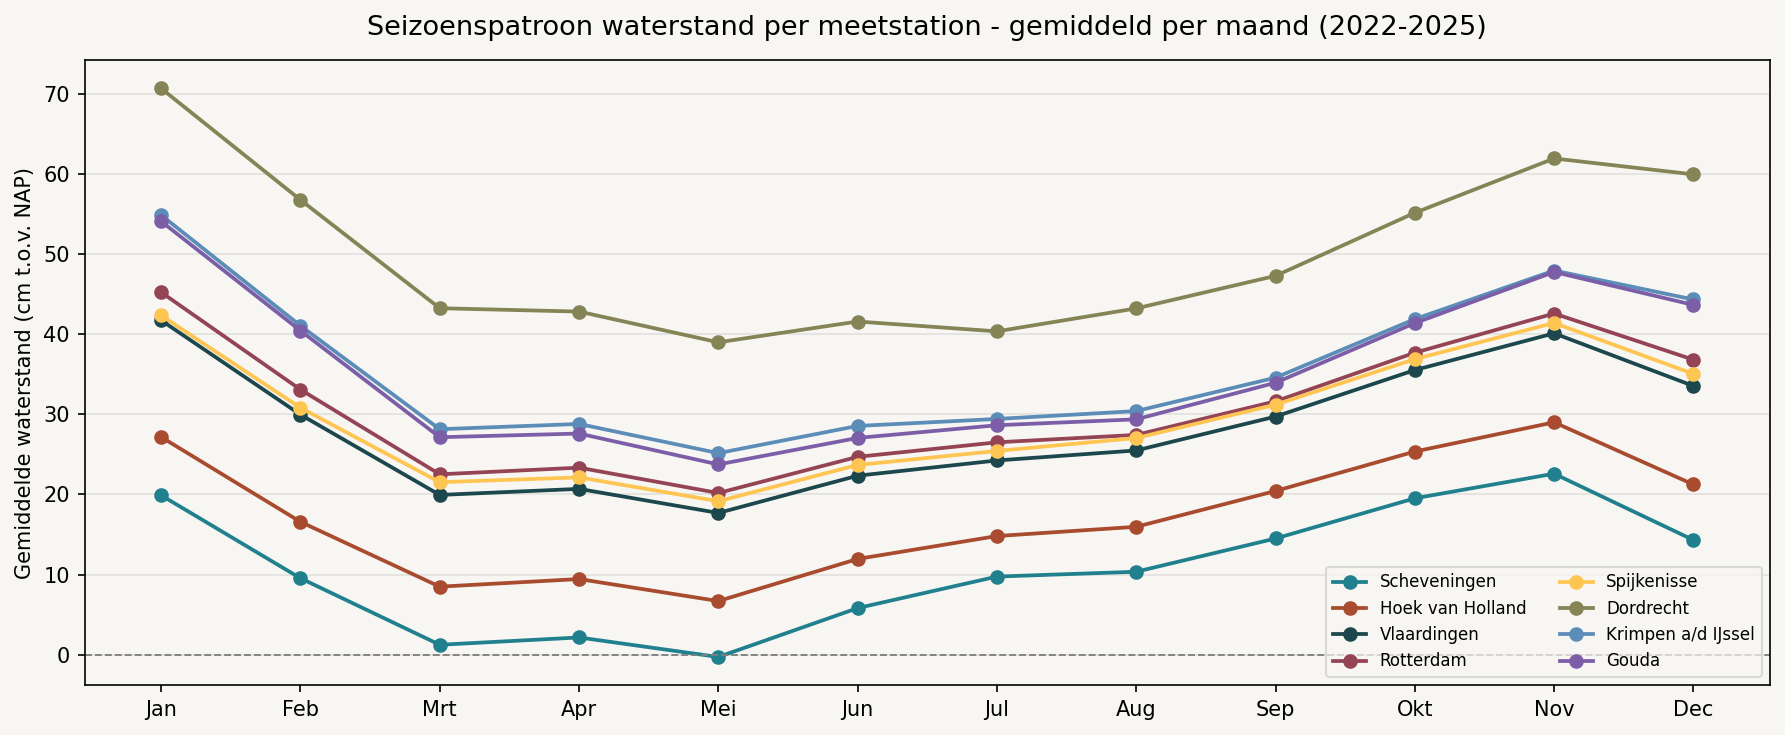

In [10]:
maandpatroon = (
    silver_data
    .groupby(['meetstation_naam', 'maand'])['waterstand_cm']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=achtergrond_kleur)
ax.set_facecolor(achtergrond_kleur)

for meetstation in meetstations_volgorde:
    subset = maandpatroon[maandpatroon['meetstation_naam'] == meetstation].sort_values('maand')
    ax.plot(
        subset['maand'], subset['waterstand_cm'],
        marker='o', linewidth=1.8,
        label=meetstation, color=meetstations_kleuren.get(meetstation)
    )
    
ax.axhline(0, color='gray', linewidth=0.9, linestyle='--')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(maanden_list)
ax.set_title('Seizoenspatroon waterstand per meetstation - gemiddeld per maand' + ' (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=13, pad=12)
ax.set_ylabel('Gemiddelde waterstand (cm t.o.v. NAP)')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', ncol=2, fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.savefig(plots_path / ('vis2_seizoenspatroon' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- Het maandpatroon verschilt per meetstation, maar de niveauverschillen tussen meetstations blijven goed zichtbaar.
- In deze dataset liggen de gemeten waterstanden gemiddeld hoger in herfst en winter dan in lente en vroege zomer.
- Een mogelijke verklaring is dat er in herfst en winter vaker sprake is van meer neerslag, hogere rivierafvoer, minder verdamping en windopzet. Om dat zeker te weten is extra weer- en afvoerdata nodig.
- Deze grafiek geeft dus vooral een eerste seizoensindicatie. Voor waterschappen of provincie kan dit helpen om maanden te herkennen waarin extra aandacht voor peilbeheer nuttig kan zijn.


## Visualisatie 3 - frequentie hoge waterstanden (>P95) per maand

Onderstaande grafiek onderzoekt wanneer relatief hoge waterstanden voorkomen. Per meetstation wordt de eigen 95e percentielwaarde gebruikt als drempel. Daardoor worden meetstations met verschillende basisniveaus eerlijker vergeleken.


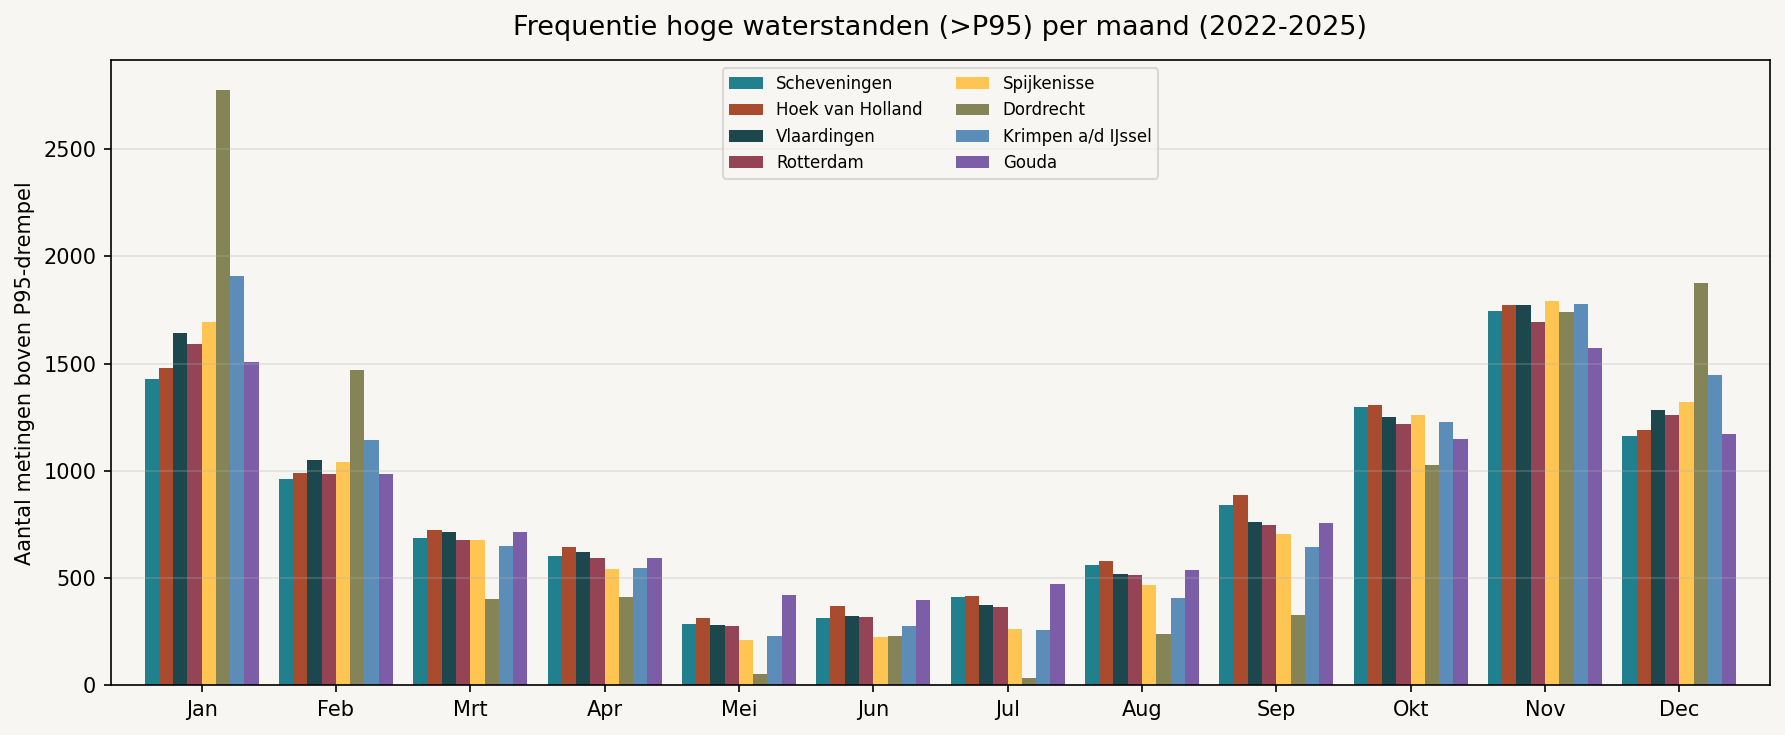

In [11]:
# Per meetstation bepalen we een eigen P95-drempel voor hoge waterstanden.
p95 = silver_data.groupby('meetstation_naam')['waterstand_cm'].quantile(0.95).rename('p95')
extremen = silver_data.join(p95, on='meetstation_naam')
extremen = extremen[extremen['waterstand_cm'] > extremen['p95']]

extremen_maand = (
    extremen
    .groupby(['maand', 'meetstation_naam'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)
extremen_maand = extremen_maand[[s for s in meetstations_volgorde if s in extremen_maand.columns]]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=achtergrond_kleur)
extremen_maand.plot(
    kind='bar', ax=ax,
    color=[meetstations_kleuren.get(meetstation) for meetstation in extremen_maand.columns],
    width=0.85,
)
ax.set_title('Frequentie hoge waterstanden (>P95) per maand (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=13, pad=12)
ax.set_ylabel('Aantal metingen boven P95-drempel')
ax.set_xlabel('')
ax.set_xticklabels(maanden_list, rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', ncol=2, fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.savefig(plots_path / ('vis3_extremen_maand' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- Hoge-watermomenten zijn niet gelijk verdeeld over het jaar. In deze dataset komen ze vaker voor in herfst- en wintermaanden.
- Omdat elk meetstation een eigen P95-drempel heeft, gaat het om relatief hoge waarden voor dat specifieke meetstation.
- De grafiek laat niet direct zien waardoor de hoge waterstanden ontstaan. Mogelijke vervolgstappen zijn een vergelijking met storm, windrichting, neerslag of rivierafvoer.
- Als eenvoudige indicator kan deze plot helpen om snel te zien in welke maanden hoge waterstanden vaker voorkomen.


## Visualisatie 4 - gemiddeld uurprofiel Hoek van Holland

Onderstaande grafiek bekijkt Hoek van Holland op uurbasis. Dit meetstation is gekozen omdat het aan de kust ligt en de getijbeweging daar duidelijk zichtbaar is.


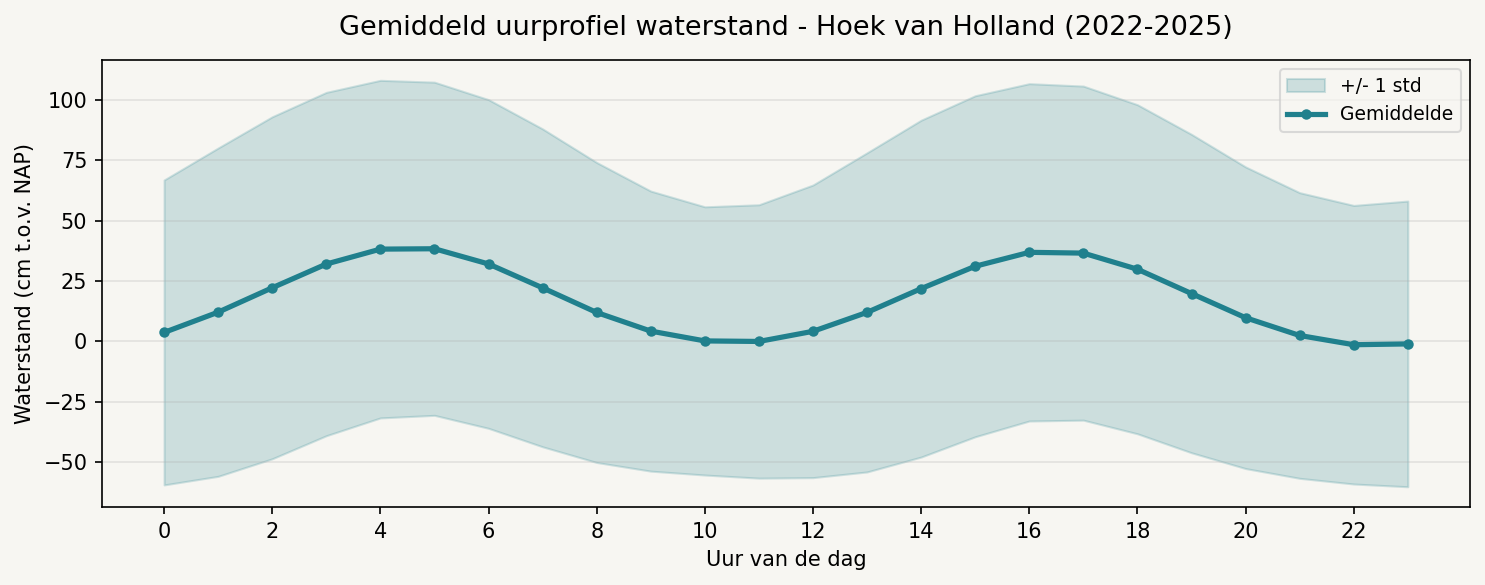

In [12]:
meetstation_profiel = 'Hoek van Holland'
hvh = silver_data[silver_data['meetstation_naam'] == meetstation_profiel]

uurprofiel = (
    hvh
    .groupby('uur')['waterstand_cm']
    .agg(gemiddelde='mean', std='std')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4), facecolor=achtergrond_kleur)
ax.set_facecolor(achtergrond_kleur)
ax.fill_between(
    uurprofiel['uur'],
    uurprofiel['gemiddelde'] - uurprofiel['std'],
    uurprofiel['gemiddelde'] + uurprofiel['std'],
    alpha=0.2, color=grafiek_kleuren[0], label='+/- 1 std'
)
ax.plot(
    uurprofiel['uur'], uurprofiel['gemiddelde'],
    color=grafiek_kleuren[0], linewidth=2.5, marker='o', markersize=4,
    label='Gemiddelde'
)
ax.set_title('Gemiddeld uurprofiel waterstand - Hoek van Holland (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=13, pad=12)
ax.set_xlabel('Uur van de dag')
ax.set_ylabel('Waterstand (cm t.o.v. NAP)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9, framealpha=0.7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plots_path / ('vis4_uurprofiel_hvh' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- Het gemiddelde uurprofiel laat zien dat waterstanden binnen een dag sterk kunnen vari?ren.
- De band met plus/min ??n standaarddeviatie laat zien dat hetzelfde uur niet altijd dezelfde waterstand heeft.
- Dit maakt duidelijk dat daggemiddelden nuttig zijn voor overzicht, maar pieken en dalen kunnen verbergen.
- Voor waarschuwingen of operationele sturing zijn daarom metingen per uur of per 10 minuten vaak belangrijker dan alleen daggemiddelden.


## Visualisatie 5 - meetstations in Zuid-Holland op kaart

Onderstaande kaart laat zien waar de gekozen meetstations liggen. De kleur geeft de gemiddelde gemeten waterstand weer. Zo krijgen de tijdreeksen ook ruimtelijke context.


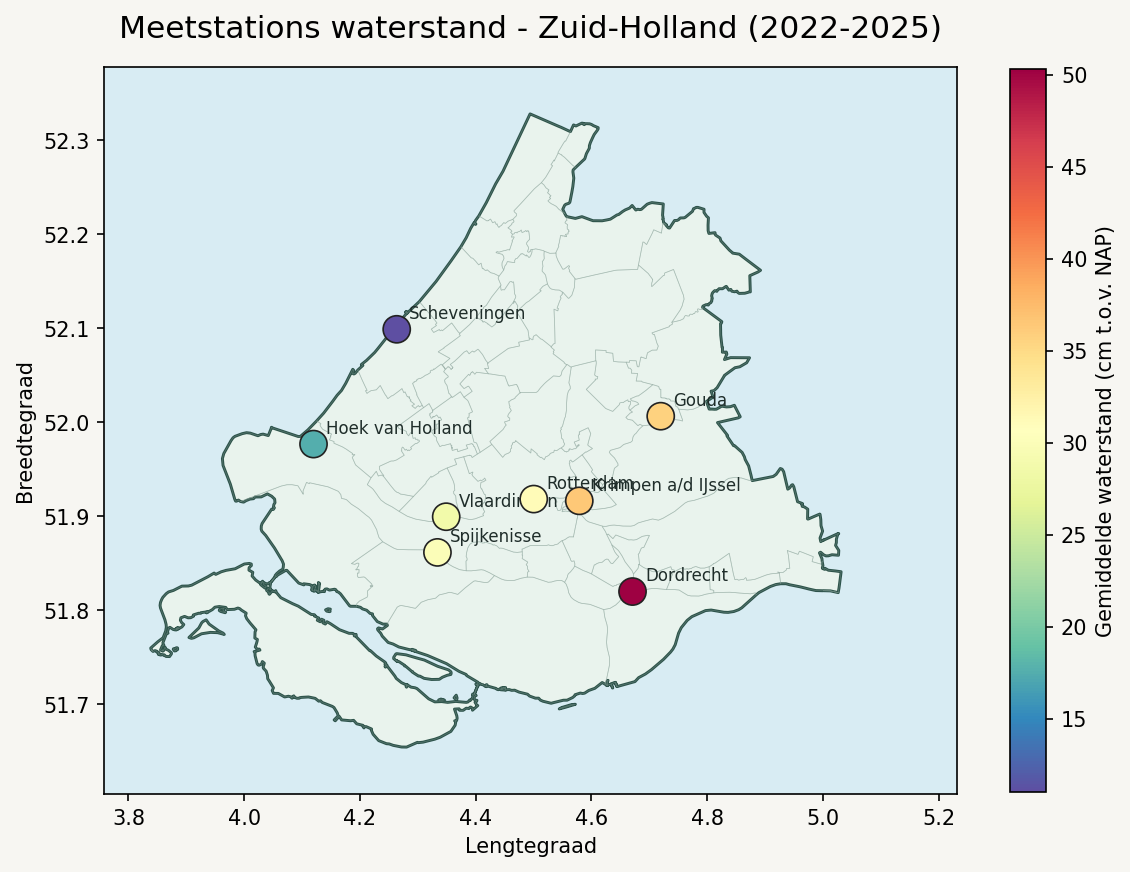

In [13]:
# Plot 5: Meetstations waterstand - Zuid-Holland
from io import BytesIO

import requests

try:
    import geopandas as gpd
except ImportError:
    gpd = None

gem_loc = silver_data.groupby(['meetstation_naam', 'lat', 'lon'])['waterstand_cm'].mean().reset_index()
gem_loc = gem_loc.rename(columns={'waterstand_cm': 'gemiddelde_cm'})

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor('#D8ECF3')

province = None
municipalities = None
if gpd is not None:
    try:
        base_url = 'https://service.pdok.nl/cbs/gebiedsindelingen/2024/wfs/v1_0'
        params = {
            'service': 'WFS',
            'version': '2.0.0',
            'request': 'GetFeature',
            'outputFormat': 'application/json',
        }
        province_resp = requests.get(
            base_url,
            params={**params, 'typeName': 'gebiedsindelingen:provincie_gegeneraliseerd',
                    'CQL_FILTER': "statcode='PV28'"},
            timeout=30,
        )
        province_resp.raise_for_status()
        province = gpd.read_file(BytesIO(province_resp.content)).to_crs('EPSG:4326')
        if 'statcode' in province.columns:
            province = province[province['statcode'] == 'PV28'].copy()

        municipality_resp = requests.get(
            base_url,
            params={**params, 'typeName': 'gebiedsindelingen:gemeente_gegeneraliseerd'},
            timeout=30,
        )
        municipality_resp.raise_for_status()
        all_municipalities = gpd.read_file(BytesIO(municipality_resp.content)).to_crs('EPSG:4326')
        municipalities = gpd.clip(all_municipalities, province)
    except Exception as exc:
        print(f'Grenzen konden niet worden geladen ({exc}); kaart wordt zonder grenzen gemaakt.')

if province is not None and not province.empty:
    province.plot(ax=ax, color='#EAF4ED', edgecolor='#244B42', linewidth=1.4, alpha=0.95)
    if municipalities is not None and not municipalities.empty:
        municipalities.boundary.plot(ax=ax, color='#8AA39A', linewidth=0.35, alpha=0.45)

scatter = ax.scatter(
    gem_loc['lon'], gem_loc['lat'],
    c=gem_loc['gemiddelde_cm'],
    cmap='Spectral_r',
    s=170,
    edgecolors='#222222',
    linewidth=0.8,
    zorder=5,
)
for _, rij in gem_loc.iterrows():
    ax.annotate(
        rij['meetstation_naam'],
        (rij['lon'], rij['lat']),
        xytext=(6, 5),
        textcoords='offset points',
        fontsize=8,
        color='#1F2D2A',
    )

fig.colorbar(scatter, ax=ax, label='Gemiddelde waterstand (cm t.o.v. NAP)', shrink=0.72)
ax.set_xlabel('Lengtegraad')
ax.set_ylabel('Breedtegraad')
ax.set_title('Meetstations waterstand - Zuid-Holland (' + str(jaartallen[0]) + '-' + str(jaartallen[-1]) + ')', fontsize=15, pad=14)
if province is not None and not province.empty:
    minx, miny, maxx, maxy = province.total_bounds
    ax.set_xlim(minx - 0.08, maxx + 0.20)
    ax.set_ylim(miny - 0.05, maxy + 0.05)
else:
    ax.set_xlim(3.75, 5.25)
    ax.set_ylim(51.60, 52.38)
fig.tight_layout()
fig.savefig(plots_path / ('vis5_kaart' + '_' + str(jaartallen[0]) + '_' + str(jaartallen[-1]) + '.png'), dpi=150, bbox_inches='tight')
plt.show()


Observaties:
- De meetstations liggen grofweg van kust naar binnenland. Daardoor is de selectie geschikt voor een eenvoudige vergelijking tussen verschillende typen locaties.
- De gemiddelde waterstand verschilt per meetstation. Dat past bij het idee dat ligging, getij-invloed, rivierinvloed en lokale omstandigheden belangrijk zijn.
- De kaart is vooral bedoeld als context bij de grafieken. Voor een uitgebreidere ruimtelijke analyse zouden bijvoorbeeld ook grenzen van waterschappen, gemeenten of watersystemen kunnen worden toegevoegd.


## Samenvatting & Conclusies

### Belangrijkste bevindingen

- De gemeten waterstanden zijn duidelijk grilliger dan de astronomische waterhoogte. Dat komt waarschijnlijk doordat gemeten waterstanden ook worden be?nvloed door onder meer wind, rivierafvoer en lokale omstandigheden.
- De astronomische waterhoogte laat een regelmatiger getijpatroon zien. Deze reeks helpt om het verschil tussen berekend getij en gemeten waterstand beter te begrijpen.
- In deze dataset liggen gemiddelde waterstanden en relatief hoge-watermomenten vaker hoger in herfst en winter.
- Dat seizoenspatroon kan samenhangen met meer neerslag, hogere rivierafvoer, minder verdamping en windopzet. Met alleen waterstandsdata kan ik dat nog niet bewijzen.
- De selectie van meetstations geeft een eenvoudige route van kust naar binnenland. Daardoor worden verschillen tussen locaties zichtbaar.
- Vanaf 2025 is bij enkele meetstations een verandering zichtbaar in de astronomische waterhoogte. Mogelijk komt dit door de brondata of berekening. Dit is een aandachtspunt voor verdere controle.

### Wat ik hiermee laat zien

Met dit project laat ik vooral zien dat ik openbare data kan ophalen, structureren en analyseren in een reproduceerbare pipeline. De hydrologische interpretatie blijft verkennend: ik gebruik de grafieken om patronen te herkennen en vervolgvragen te formuleren.


## Productievoorbeeld met Prefect

Naast deze notebook staat er ook een kleine Prefect-flow in `src/prefect_flow.py`. Die flow voert dezelfde hoofdstructuur uit als de notebook: Bronze-data laden, Silver-data maken en Gold-tabellen schrijven.

Dit is geen volledige productie-omgeving. Het is bedoeld als eenvoudig voorbeeld van hoe een notebook-pipeline later kan worden opgesplitst in losse taken. In een echte productieomgeving zouden daar bijvoorbeeld logging, planning, foutafhandeling en monitoring bij komen.


In [14]:
# Voorbeeld: de echte Prefect-flow uit het project importeren.
# Deze cel hoeft niet opnieuw te draaien voor de analyse hierboven.

from src.prefect_flow import waterstand_pipeline

# De flow kan lokaal worden gestart met:
# resultaat = waterstand_pipeline()
# print(resultaat)

print('Prefect-flow beschikbaar: src/prefect_flow.py')


Prefect voorbeeld: in productie kunnen Bronze, Silver en Gold als geplande taken draaien.


## Mogelijke uitbreidingen

- Gemeten waterstand vergelijken met wind, luchtdruk, neerslag of rivierafvoer.
- Formele alarmpeilen of beheergrenzen toevoegen aan de visualisaties.
- Alleen meetstations tonen waarvoor astronomische waterhoogte stabiel en goed interpreteerbaar is.
- Grenzen van waterschappen, gemeenten of watersystemen toevoegen aan de kaart.
- De Django-app beperken tot een eenvoudige presentatie van de belangrijkste visualisaties.
